# The Effects of Student Habits on Academic Performance
## Spring 2026 Data Science Project
### Names: Samuel Dupont, Sarah Pham, Drew Owens, Owen Marzolf-Miller, Anjana Rajah

#### Contributions:
Samuel - I did ...

Sarah - I did ...

Drew - I did ...

Owen - I helped work on the project idea, data curation, and final tutorial report creation. Specifically, I worked on the python notebook to explore the student lifestyle dataset and performed some preprocessing on the dataset, I also helped write several parts of the final report.

Anjana - I did ...



#### Introduction:

We are examining the lifestyle habits of students and their academic performances. Specifically, we are trying to learn and find if any relationships exist between the lifestyle habits, which are our independent variables in this study, and the students' academic performances, which are our dependent variables. The habits include: study hours, sleep duration, screen time, physical activity, diet type, and stress level; the performance measures include: attendance percentage, internal marks, and CGPA (cumulative GPA). Through analysis, we want to find which lifestyle characteristics have a positive impact on CGPA, which is our primary focus from attendance and internal marks.

Through our exploration, finding these relationships can help reveal which student habits will be more beneficial to promoting academic wellness, and can be applied to outside of this study to help students improve academically.

In [2]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("student_lifestyle_performance_dataset.csv")
display(df)
display(df.dtypes)

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77
...,...,...,...,...,...,...,...,...,...,...,...,...
995,24,IT,4.60,5.26,4.23,12.64,Non-Veg,82.95,7.12,Day Scholar,69.63,6.65
996,17,IT,4.02,6.55,3.88,2.86,Non-Veg,89.29,4.19,Hosteller,66.97,7.77
997,25,CSE,4.28,8.43,4.64,0.00,Veg,74.57,2.80,Day Scholar,80.52,8.04
998,23,Civil,6.42,6.06,4.84,10.08,Non-Veg,91.57,6.76,Day Scholar,77.48,7.24


Age                        int64
Branch                    object
Study_Hours_per_Day      float64
Sleep_Hours              float64
Screen_Time_Hours        float64
Gym_Hours_per_Week       float64
Diet_Type                 object
Attendance_Percentage    float64
Stress_Level_1_to_10     float64
Residence                 object
Internal_Marks           float64
CGPA                     float64
dtype: object

Examining our dataset of 1000 rows and 12 columns, we fortunately did not encounter any
missing values or incorrect data types, so no data cleaning was required. The dataset contains
a mix of numeric features (int64 and float64) such as Age, Study_Hours_per_Day, Sleep_Hours,
and CGPA, as well as categorical features (object) such as Branch, Diet_Type, and Residence.

# Exploring University Students' Internal Marks

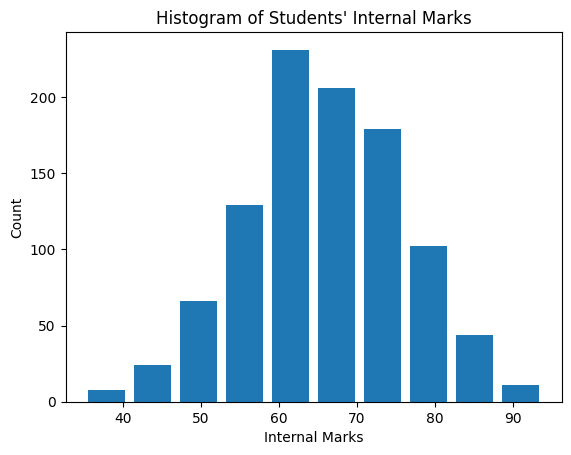

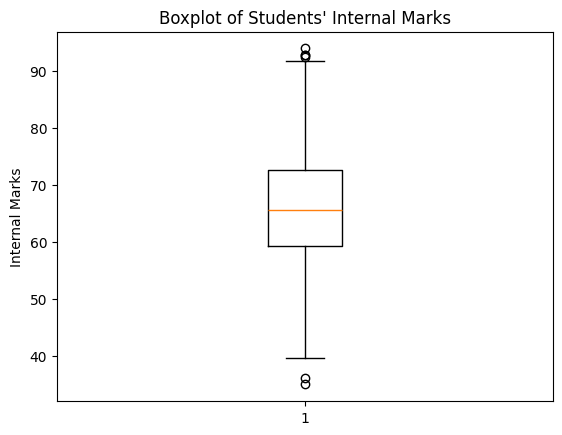

count    1000.000000
mean       65.922380
std        10.123247
min        35.000000
25%        59.330000
50%        65.600000
75%        72.547500
max        93.930000
Name: Internal_Marks, dtype: float64

In [4]:
plt.hist(df["Internal_Marks"], rwidth=0.8)
plt.xlabel("Internal Marks")
plt.ylabel("Count")
plt.title("Histogram of Students' Internal Marks")
plt.show()

plt.boxplot(df["Internal_Marks"])
plt.ylabel("Internal Marks")
plt.title("Boxplot of Students' Internal Marks")
plt.show()

df["Internal_Marks"].describe()

Looking at the above plots it seems that internal marks are roughly normally distributed, which is what we would expect for a grade distribution. The histogram shows a bell curve shape, with the boxplot showing a very equal distribution above and below the mean with outliers on both ends. 

The data formatting this well could indicate some type of grade curving to cluster grades around a central mean, which in this case is about 65.9 with a standard deviation of about 10.1.

# Calculating the Relationship Between Study Hours and CGPA

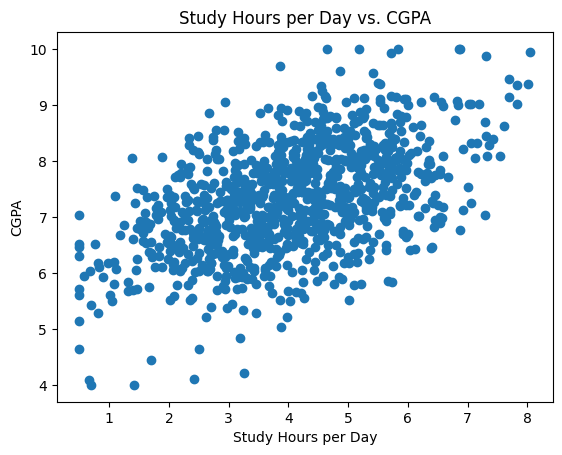

Pearson Correlation Coefficient: 0.5066084567902694
P-Value: 2.6375680323221514e-66


In [5]:
plt.scatter(df["Study_Hours_per_Day"], df["CGPA"])
plt.xlabel("Study Hours per Day")
plt.ylabel("CGPA")
plt.title("Study Hours per Day vs. CGPA")
plt.show()

r, p = stats.pearsonr(df["Study_Hours_per_Day"], df["CGPA"])
print("Pearson Correlation Coefficient: " + str(r))
print("P-Value: " + str(p))

First, we can see from the scatterplot above that there is a positive correlation between study hours per day and CGPA.

The Pearson Correlation Coefficient of 0.51 between study hours per day and CGPA
indicates a moderate positive linear relationship. This means that as the number of study hours
per day increases, CGPA tends to increase as well, though not perfectly. Other factors likely
also contribute to academic performance.

***Confirming with Hypothesis Test***

$H_0$ (Null): There is no linear relationship between daily study hours and CGPA ($\rho$ = 0)

$H_a$ (Alternative): There is a positive linear relationship between daily study hours and CGPA ($\rho$ > 0)

Since the p-value is approx. 0 which is less than $\alpha$ = 0.05, we can reject the null. It can be concluded there is a statistically significant, moderately increasing relationship between a student's study hours per day and CGPA. In other words, increasing one's study hours per day can be expected to moderately increase CGPA.

# Analyzing How CGPA Differs Between Diet Types, Branch, and Residence

Diet_Type ANOVA
p-value is:  0.4157898295580138

Branch ANOVA
p-value is:  0.023983468971934884

Residence ANOVA
p-value is:  0.40139423186053136


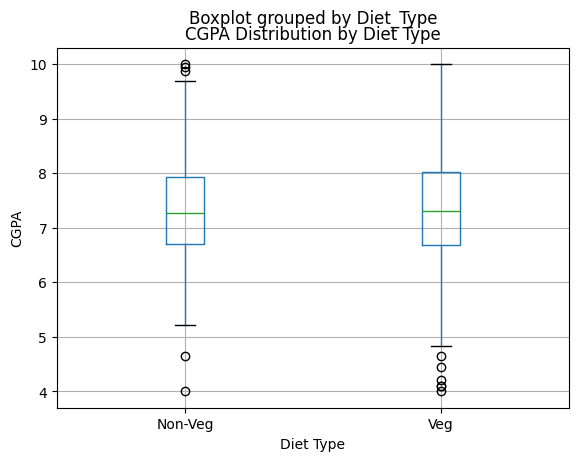

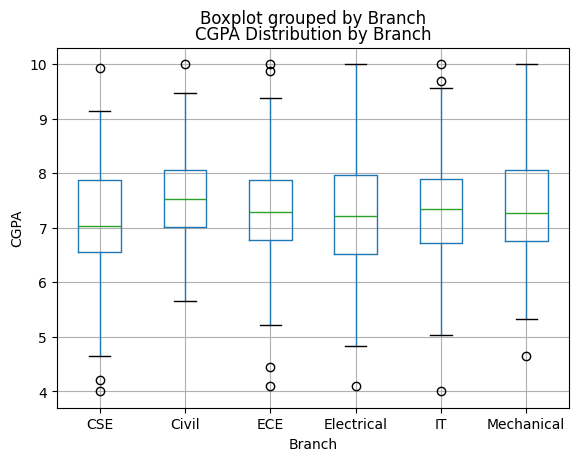

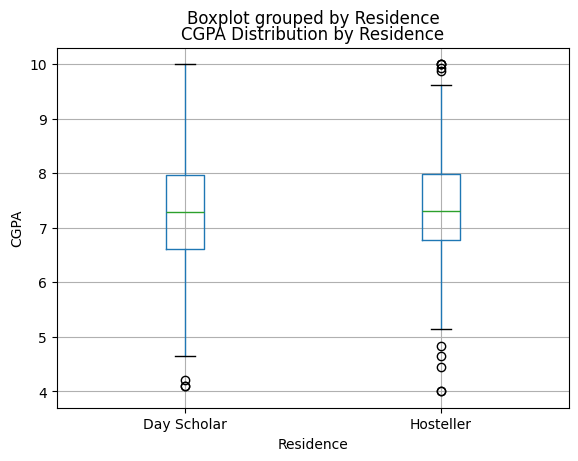

In [6]:
'''Diet Type Section'''

g1 = df.groupby('Diet_Type')['CGPA'].apply(list)
fstat1, pval1 = stats.f_oneway(*g1)
print("Diet_Type ANOVA")
print("p-value is: ", pval1)

# Plot for Diet_Type
df.boxplot(column="CGPA", by="Diet_Type")
plt.title("CGPA Distribution by Diet Type")
plt.xlabel("Diet Type")
plt.ylabel("CGPA")

'''Branch Section'''

g2 = df.groupby('Branch')['CGPA'].apply(list)
fstat2, pval2 = stats.f_oneway(*g2)
print("\nBranch ANOVA")
print("p-value is: ", pval2)

# Plot for Branch
df.boxplot(column="CGPA", by="Branch")
plt.title("CGPA Distribution by Branch")
plt.xlabel("Branch")
plt.ylabel("CGPA")

'''Residence Section'''

g3 = df.groupby('Residence')['CGPA'].apply(list)
fstat3, pval3 = stats.f_oneway(*g3)
print("\nResidence ANOVA")
print("p-value is: ", pval3)

# Plot for Residence
df.boxplot(column="CGPA", by="Residence")
plt.title("CGPA Distribution by Residence")
plt.xlabel("Residence")
plt.ylabel("CGPA")

plt.show()


***ANOVA Tests***

##### Diet Type:
$H_0$: The mean CGPA is the same across all diet types

$H_a$: The mean CGPA differs for at least one diet type


##### Residency Type:
$H_0$: The mean CGPA is the same across all residency types

$H_a$: The mean CGPA differs for at least one residency type

Looking at the p-values for Diet Type and Residency in the ANOVA tests above, both are greater than $\alpha$ = 0.05 (0.42 and 0.40, respectively). Thus, we fail to reject the null hypothesis for both tests. There is insufficient evidence to conclude that mean CGPA differs across diet types or residency types.


##### Branch:
$H_0$: The mean CGPA is the same across all branches.

$H_a$: The mean CGPA differs for at least one branch.


Since p = 0.02 < $\alpha$ = 0.05, we reject the null hypothesis. There is sufficient evidence to conclude that mean CGPA differs significantly across branches (majors).

The boxplots serve as visual support, showing greater variation in mean CGPA across branches compared to the relatively uniform distributions seen for diet type and residency.


# Primary Analysis
## Using a Random Forest to predict CGPA
From our EDA it is clear that some factors have more impact on CGPA than others, but that generally there is a relationship between student habits and CGPA. Since it's likely a complex relationship that relates to many different features, we decided to use an ML model for our analysis. Specifically, we decided to use a random forest model as it provides the ability to detect non-linear relationships with the ease of using a decision tree model but without the need to tune out overfitting. A neural network would also work well here, but we felt it would be more useful to show that this relationship can be found with high accuracy without the computational power needed to train a neural network. In this section we train a random forest regressor and test its accuracy on our dataset using an 80/20 train-test split.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [8]:
# Creating our input and target datasets by splitting off the "CGPA" column
X = df.drop(columns=["CGPA"])
y = df["CGPA"]

# We used 1-hot encoding to handle categorical variables like branch and diet type
X = pd.get_dummies(X)

# 80/20 train-test split for evaluating our model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [13]:
# Initializing our model and fitting it on our training data
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predicting the CGPA's of our test data
preds = model.predict(X_test)

# Finding the mean squared error and r^2 score of our predictions relative 
# to the true values
mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

# We used mean squared error and r^2 score to quantify the accuracy of our model
print("MSE:", mse)
print("R^2 Score:", r2)

MSE: 0.20139577029999964
R^2 Score: 0.8231468970352873


# Visualization
## Visualizing the Accuracy of our Model's Predictions
In this section we use a scatter plot to compare our model's predictions vs. the true values of CGPA. Our scatter plot includes the raw prediction values in blue, a best-fit line of these predictions in green, and a line symbolizing perfect predictions in red. As can be seen from our scatter plot there is certainly some variability in our predictions, however we are able to predict a roughly accurate CGPA (within about 1 point) based only on students' habits.

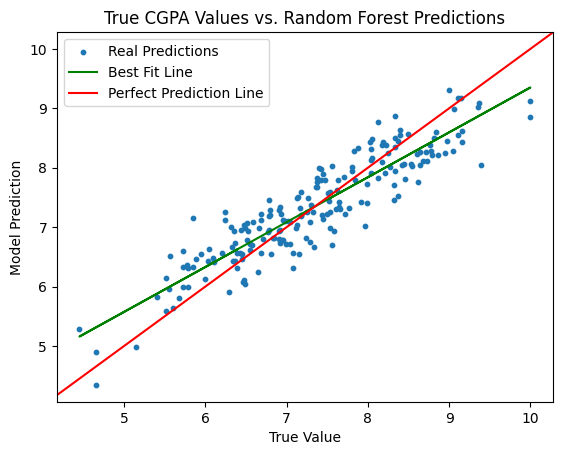

In [20]:
# Creating a basic scatter plot with size 10 dots and adding labeling
plt.scatter(y_test, preds, label = "Real Predictions", s = 10)
plt.ylabel("Model Prediction")
plt.xlabel("True Value")
plt.title("True CGPA Values vs. Random Forest Predictions")

# Creating a best fit line of our scatter plot in green
m, b = np.polyfit(y_test, preds, 1)
plt.plot(y_test, m*y_test + b, color = "green", label = "Best Fit Line")

# Creating a perfect prediction line (y=x) in red
plt.axline([5, 5], [10, 10], color = "red", label = "Perfect Prediction Line")

plt.legend()
plt.show()